In [1]:
import math
import numpy as np
import pandas as pd
from typing import Optional, Any, List, Union, Literal, DefaultDict
import warnings
import statistics
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
import sklearn.metrics as metrics
import statistics as st
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.utils._testing import ignore_warnings
from sklearn.exceptions import ConvergenceWarning

In [2]:
#https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html
class Node:
    """
    Nodo de un árbol de decisión, ya sea 
        - un nodo hoja (que guarda un conjunto de valores posibles
          junto con sus probabilidades), o 
        - un nodo de decisión (que divide el espacio de búsqueda utilizando
          un umbral sobre un determinado feature o atributo).

    Args:
        - value: valores asociados a un nodo hoja.
        - probs: probabilidades de cada uno de los valores de un nodo hoja.
        - children: cada uno de los nodos hijos de un nodo de decisión.
        - feature: índice del atributo sobre el que se divide el espacio 
          de búsqueda en un nodo de decisión. Debe ser None en nodos hojas.
        - threshold: umbral utilizado para dividir el espacio de búsqueda
          sobre la dimensión especificada. Se puede utilizar un float 
          (para dividir atributos continuos en dos hijos), o una lista 
          de posibles valores (para dividir atributos discretos).
    """

    def __init__(
        self, 
        value : Optional[List] = None,
        probs : Optional[List[float]] = None,
        children : List['Node'] = [], 
        feature : Optional[int] = None,
        threshold : Optional[Union[float,int,List]] = None,
    ):        
        self.value = value
        self.probs = probs
        self.children = children
        self.feature = feature
        self.threshold = threshold

        if value is not None and len(value) > 0:
            self._is_leaf = True
            assert not children and not feature and not threshold, \
                "Un nodo hoja no puede tener hijos"
            assert probs is not None, "Un nodo hoja debe especificar probabiliades"
            assert len(value) == len(probs)
        else:
            self._is_leaf = False
            if isinstance(threshold, float) or isinstance(threshold, int):
                assert len(children) == 2, "Con un umbral continuo solo puede haber \
                    dos hijos (el >= y el <)"
            else:
                assert len(children) == len(threshold), "Con un umbral discreto tiene \
                    que haber tantos hijos como clases"

    def is_leaf(self):
        return self._is_leaf
    
    def max_depth(self):
        return 0 if self._is_leaf else max([1+c.max_depth() for c in self.children])
    
    def min_depth(self):
        return 0 if self._is_leaf else min([1+c.min_depth() for c in self.children])

    def avg_depth(self):
        return 0 if self._is_leaf else np.average([1+c.avg_depth() for c in self.children])

    def num_leafs(self):
        return 1 if self._is_leaf else sum([c.num_leafs() for c in self.children])

    def _predict(self, x : List[Any], verbose=False, get_probs=False):
        """
        Dado un dato con un conjunto de atributos, devolver los posibles valores
        predichos junto a sus probabilidades.

        Si get_probs es False, se devuelve la predicción más probable.
        """

        if self.is_leaf():
            # Si es un nodo hoja, simplemente se devuelve las probabilidades.
            if get_probs:
                return (self.value, self.probs)
            else:
                return self.value[np.argmax(self.probs)]
        elif isinstance(self.threshold, float) or isinstance(self.threshold, int):
            if verbose:
                print(x, self.feature, self.threshold)
            # Si es un nodo de decisión basado en un umbral, coger uno de los
            # dos hijos en base a si el valor es mayor o inferior al umbral.
            idx_child = int(x[self.feature] > self.threshold)
            return self.children[idx_child].predict(x, verbose, get_probs)
        else:
            if verbose:
                print(x, self.feature, self.threshold)
            # Si es un nodo de decisión, y el umbral es una lista de valores
            # discretos, buscar en el hijo que corresponda a la clase.
            idx_child = self.threshold.index(x[self.feature])
            return self.children[idx_child].predict(x, verbose, get_probs)
            
    def predict(self, x : Union[np.array,pd.DataFrame], verbose=False, get_probs=False):
        """
        Dado varios datos, predecir el valor más probable para cada uno de ellos..
        """
        if len(x.shape) == 1:
            return self._predict(x, verbose, get_probs)
        else:
            if isinstance(x, pd.DataFrame):
                x = x.to_numpy()
            return [self._predict(x_row, verbose, get_probs) for x_row in x]

    def print_tree(self, depth=0, divider = "root") -> None:
        if self._is_leaf == True:
            print(f"|{'--'*depth}> Leaf node ({divider})\n|{'  '*depth}|--> class: {self.value} with probs {self.probs}")
            return
        print(f"|{'--'*depth}> ({divider}) Decision Node - Divided by threshold {self.threshold} on feature [:,{self.feature}] (dataset column)")
        if hasattr(self.threshold, "__len__"):
            for i, child in enumerate(self.children):
                child.print_tree(depth+1, divider="c_"+str(self.threshold[i]))
        else:
            izq, der = self.children
            izq.print_tree(depth+1, divider="<= " + str(self.threshold))
            der.print_tree(depth+1, divider="> " + str(self.threshold))

In [3]:
class Theshold:
    """
    Clase que representa todos los posibles umbrales de cada uno de los atributos
    *continuos* de un dataset que se van a probar al construir un árbol de decisión.
    Los atributos *discretos* se ignoran.

    Se admiten 3 estrategias distintas:
        - best: Se probarán todos los umbrales posibles para cada uno de los
          atributos.
        - custom: Se prueban sólo los umbrales especificados manualmente para
          los atributos contínuos.
        - avg: Se probarán solo 3 umbrales: la media del atributo, y la
         desviación estándar por encima y por debajo de la media.
    """

    def __init__(
        self, 
        type : Literal["best", "custom", "avg"] = 'best', 
        th_array : List[List] = None
    ) -> None:
        self.type = type
        self.th_array = th_array
        assert not th_array or type == "custom", "Solo se pueden \
            especificar umbrales si la estrategia es 'custom'"

    def _fit_array(self, data : np.array):   
        if self.type == "best":
            # Para cada columna añadir todos los valores posibles.
            self.th_array = []
            for i in range(data.shape[1]-1):
                self.th_array.append(np.unique(data[:,i]))
            # Para cada columna añadir todos los valores posibles.
            self.th_array = []
            for i in range(data.shape[1]-1):
                # Valores únicos ordenados
                values = np.unique(data[:,i])
                # Establecer los umbrales como la media entre valores contiguos
                self.th_array.append((values[:-1] + values[1:]) / 2)
        elif self.type == "custom":
            # Comprobar que se han especificado una cantidad suficiente
            # de umbrales para los atributos contínuos. En el caso de
            # que no se hayn indicado atributos para todas las columnas,
            # rellenar las que faltan con la estrategia "avg".
            size_flag = 0
            for i in range(data.shape[1]-1):
                if type(data[:,i][0]) == str:
                    continue
                elif i < len(self.th_array):
                    th_column_tam = len(self.th_array[i])
                    if th_column_tam < 3:
                        warnings.warn(f"threshold {i} column tiene pocos valores")
                else:
                    size_flag = 1
                    media, stdev =  np.mean(data[:,i]), statistics.stdev(data[:,i])
                    self.th_array.append([media - stdev, media, media + stdev])
            if size_flag:
                warnings.warn(f"custom threshold columnas faltantes, autorelleno con avg type")
        elif self.type == "avg":
            # Para cada columna que no sea un atributo discreto,
            # añadir como umbral la media, y la desviación estándar
            # por encima y por debajo de la media.
            self.th_array = []
            for i in range(data.shape[1]-1):
                if type(data[:,i][0]) == str:
                    self.th_array.append([])
                else:
                    media, stdev =  np.mean(data[:,i]), statistics.stdev(data[:,i])
                    self.th_array.append([media - stdev, media, media + stdev])


In [4]:
def entropy(y : np.array) -> float:
    """
    Calcula la entropia de un conjunto de etiquetas para
    cuantificar cómo de uniforme es el conjunto.

    Una entropía de 0 es un conjunto de datos perfectamente 
    uniforme. Cuanto más variado sea el conjunto, mayor 
    la entropía.
    """

    lables, label_counts = np.unique(y, return_counts=True)
    
    entropy = 0.0
    if len(lables) <= 1:
        return entropy
    
    num_samples = len(y)
    probs = label_counts / num_samples

    for prob in probs:
        entropy += -prob * np.log2(prob)

    return entropy

def gini(y : np.array) -> float:
    """
    Calcula la impuridad de Gini de un conjunto de etiquetas.

    Este calcula la probabilidad de que una etiqueta elegida
    aleatoriamente sea clasificada incorrectamente al elegir
    otra etiqueta aleatoriamente. Si todas las etiquetas son
    iguales, la probabilidad es 0. Si todas las etiquetas
    son distintas, la probabilidad es 1.
    """

    num_samples = len(y)
    lables, label_counts = np.unique(y, return_counts=True)

    gini = 0.0
    if len(lables) <= 1:
        return gini
    
    probs = label_counts / num_samples
    for prob in probs:
        gini += prob*prob

    return 1 - gini

def information_gain(x : np.array, x_division : List[np.array], type : Literal["entropy","gini"] = "entropy" ):
    """
    Calcula la ganancia de información de dividir un conjunto de etiquetas en
    varios subconjuntos, determinado como la información del conjunto completo,
    menos la información de cada uno de los subconjuntos.
    """
    ratios = np.array([len(division) / len(x) for division in x_division])
    if type == "entropy":
        return entropy(x) - sum(ratios * np.array([entropy(division) for division in x_division]))
    if type == "gini":
        return gini(x) - sum(ratios * np.array([gini(division) for division in x_division]))

In [5]:
class DecisionTree:
    """
    Clase que permite crear un árbol de decisión en base a unos datos de entrenamiento.

    Args:
        - min_info_gain: mínima cantidad de información que se debe ganar al dividr un
          nodo para que la división se produzca.
        - max_depth: la máxima profundidad del árbol. Si no se especifica, no se limita
          la profundidad del árbol.
        - min_samples_split: la mínima cantidad de valores que tiene que tener un nodo
          para que éste se pueda dividir en varios nodos hijos.
        - min_samples_leaf: número mínimo de valores que debe tener un nodo hoja.
        - criterion: criterio utilizado para calcular la ganancia de información
          al dividir el espacio de búsqueda. Puede ser entropía o impuridad de Gini.
    """

    def __init__(
        self, 
        min_info_gain:float,
        max_depth:Optional[int]=None,
        min_samples_split:int=2, 
        min_samples_leaf:int=1,
        criterion:Literal["entropy","gini"] = "entropy"
    ):
        self.min_info_gain = min_info_gain
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.criterion = criterion

        assert self.min_samples_split > self.min_samples_leaf

    def _create_split(
        self, 
        x : np.array, 
        column_id, 
        threshold_array : Theshold
    ) -> tuple[list, Union[float, list]]:
        """
        Dado los datos de un nodo y posibles umbrales, obtiene la mejor 
        división posible de los datos (según la mayor cantidad de 
        información ganada). 

        Se devuelven por un lado la lista de los datos separados, y el umbral
        elegido para separar los datos.
        """

        x_column = x[:,column_id]
        if type(x_column[0]) == str:
            classes = np.unique(x_column)
            return [x[x_column == name] for name in classes], classes.tolist()
        else:
            best_gain, best_th, best_left, best_right = -math.inf, None, None, None
            for th in threshold_array.th_array[column_id]:
                x_left = x[x_column <= th]
                x_right = x[x_column > th]
                if len(x_left) < 1:
                    warnings.warn(f"Threshold on column {column_id} was autobalanced (all weight was on one Node)")
                    x_left, x_right = x_right[0:1], x_right[1:]
                if len(x_right) < 1:
                    warnings.warn(f"Threshold on column {column_id} was autobalanced (all weight was on one Node)")
                    x_right, x_left = x_left[-2:-1], x_left[:-1]
                gain = information_gain(x[:,-1], [x_left[:,-1], x_right[:,-1]])
                if gain > best_gain:
                    best_gain, best_th, best_left, best_right = gain, th, x_left, x_right
            return [best_left, best_right], best_th

    def _get_leaf_value(self, x:np.array) -> tuple[np.array,np.array]:
        """
        Dado los datos de un nodo, devuelve las predicciones 
        posibles junto a sus sendas probabilidades.
        """

        y = x[:,-1]
        lables, label_counts = np.unique(y, return_counts=True)
        return lables, label_counts/len(y)

    def _build_tree(self, data:np.array, threshold_array:Theshold, depth=0) -> Node:
        """
        Genera recursivamente un nodo del árbol de decisión a partir de los 
        datos de un nodo y los umbrales a probar para dividir el espacio de búsqueda.
        """

        # Comprobar si superamos la profundidad máxima. Si sí, forzamos un nodo hoja.
        if self.max_depth and depth >= self.max_depth:
            value, probs = self._get_leaf_value(data)
            return Node(value=value, probs=probs)
        
        n_samples, n_features = np.shape(data)

        # Comprobar si tenemos datos suficientes como para dividir el espacio de 
        # búsqueda. Si no, forzamos un nodo hoja.
        if n_samples <= self.min_samples_split:
            value, probs = self._get_leaf_value(data)
            return Node(value=value, probs=probs)
        
        # Buscar el umbral óptimo para dividir el espacio de búsqueda.
        data_splits, info_gain, th, best_index = self._best_split(data, threshold_array)

        # Comprobar que la división del espacio de búsqueda nos hace ganar
        # suficiente información. Si no, forzamos un nodo hoja.
        if info_gain <= self.min_info_gain:
            value, probs = self._get_leaf_value(data)
            return Node(value=value, probs=probs)

        # Comprobar que cada una de las divisiones del espacio de búsqueda
        # tiene suficientes datos. Si no, no realizamos la división.
        for data_split in data_splits:
            n_samples, n_features = np.shape(data_split)
            if n_samples < self.min_samples_leaf:
                value, probs = self._get_leaf_value(data)
                return Node(value=value, probs=probs)

        # Si todo está bien, generar de forma recursiva los nodos de cada
        # una de las divisiones del espacio de búsqueda, y terminar.
        children = [
            self._build_tree(data_split, threshold_array, depth+1)
            for data_split in data_splits
        ]

        return Node(
            children=children, 
            threshold=th,
            feature=best_index,
        )
    
    def _best_split(self, data:np.array, threshold_array:Theshold):
        """
        Determina la forma de dividir un conjunto de datos que aumente
        más la cantidad de información ganada.

        Para ello se prueba a dividir cada atributo del conjunto de datos,
        y se prueban todos los umbrales especificados por threshold_array. 
        """

        best_information_gain = -math.inf
        for i in range(len(data[0])-1):
            split, th = self._create_split(data, i, threshold_array)
            gain = information_gain(data[:,-1], [s[:,-1] for s in split], type=self.criterion)
            if gain > best_information_gain:
                best_split, best_information_gain, best_th, best_index = split, gain, th, i
        return best_split, best_information_gain, best_th, best_index

    def fit(self, data:Union[np.array,pd.DataFrame], threshold_array:Theshold):
        data_tn = data.to_numpy()
        threshold_array._fit_array(data_tn)
        self.root = self._build_tree(data_tn, threshold_array = threshold_array)

    def predict(self, X, verbose=False, get_probs=False):
        return self.root.predict(X, verbose, get_probs)

    def print_tree(self):
        self.root.print_tree()

<h1>PRUEBAS CON LOS DATASET DEL PDF</h1>

In [6]:
data = pd.read_csv("lenses.csv")
data[0:5]

,Age,Prescription,Astigmatic,TearRate,Label
0,young,myope,no,reduced,no lenses
1,young,myope,no,normal,soft
2,young,myope,yes,reduced,no lenses
3,young,myope,yes,normal,hard
4,young,hypermetrope,no,reduced,no lenses


In [7]:
for column in data.columns:
    if type(data[column][0]) == str:
        unique_classes = data[column].unique()
        print(f"{column} -> {list(unique_classes)}")
    else:
        minmax = data[column].min(), data[column].max()
        print(f"{column} -> [{minmax[0]} - {minmax[1]}]")

Age -> ['young', 'pre-presbyopic', 'presbyopic']
Prescription -> ['myope', 'hypermetrope']
Astigmatic -> ['no', 'yes']
TearRate -> ['reduced', 'normal']
Label -> ['no lenses', 'soft', 'hard']


In [8]:
data['Age'].replace(['young', 'pre-presbyopic', 'presbyopic'], [0, 1, 2], inplace=True)
data['Prescription'].replace(['myope', 'hypermetrope'], [0, 1], inplace=True)
data['Astigmatic'].replace(['no', 'yes'], [0, 1], inplace=True)
data['TearRate'].replace(['reduced', 'normal'], [0, 1], inplace=True)
#data['Label'].replace(["no lenses", "soft", "hard"], [0, 1, 2], inplace=True)

data[0:5]

,Age,Prescription,Astigmatic,TearRate,Label
0,0,0,0,0,no lenses
1,0,0,0,1,soft
2,0,0,1,0,no lenses
3,0,0,1,1,hard
4,0,1,0,0,no lenses


In [9]:
warnings.filterwarnings("ignore")
mi_tree = DecisionTree(
    min_info_gain=0,
    max_depth=None,
    min_samples_split=1,
    min_samples_leaf=0,
)
th = Theshold(type="custom", th_array=[[1.5], [0.5], [0.5], [0.5]])
mi_tree.fit(data, threshold_array=th)

print(f"Max depth: {mi_tree.root.max_depth()}")
print(f"Min depth: {mi_tree.root.min_depth()}")
print(f"Avf depth: {mi_tree.root.avg_depth()}")
print(f"Num leafs: {mi_tree.root.num_leafs()}")

Max depth: 4
Min depth: 1
Avf depth: 2.25
Num leafs: 7


In [10]:
mi_tree.print_tree()

|> (root) Decision Node - Divided by threshold 0.5 on feature [:,3] (dataset column)
|--> Leaf node (<= 0.5)
|  |--> class: ['no lenses'] with probs [1.]
|--> (> 0.5) Decision Node - Divided by threshold 0.5 on feature [:,2] (dataset column)
|----> (<= 0.5) Decision Node - Divided by threshold 1.5 on feature [:,0] (dataset column)
|------> Leaf node (<= 1.5)
|      |--> class: ['soft'] with probs [1.]
|------> (> 1.5) Decision Node - Divided by threshold 1.5 on feature [:,0] (dataset column)
|--------> Leaf node (<= 1.5)
|        |--> class: ['no lenses'] with probs [1.]
|--------> Leaf node (> 1.5)
|        |--> class: ['soft'] with probs [1.]
|----> (> 0.5) Decision Node - Divided by threshold 0.5 on feature [:,1] (dataset column)
|------> Leaf node (<= 0.5)
|      |--> class: ['hard'] with probs [1.]
|------> (> 0.5) Decision Node - Divided by threshold 0.5 on feature [:,1] (dataset column)
|--------> Leaf node (<= 0.5)
|        |--> class: ['hard'] with probs [1.]
|--------> Leaf n

In [11]:
print(data.iloc[[9,11,20]])
mi_tree.predict(data.iloc[[9,11, 20]], verbose=True)

    Age  Prescription  Astigmatic  TearRate      Label
9     1             0           0         1       soft
11    1             0           1         1       hard
20    2             1           0         0  no lenses
[1 0 0 1 'soft'] 3 0.5
[1 0 0 1 'soft'] 2 0.5
[1 0 0 1 'soft'] 0 1.5
[1 0 1 1 'hard'] 3 0.5
[1 0 1 1 'hard'] 2 0.5
[1 0 1 1 'hard'] 1 0.5
[2 1 0 0 'no lenses'] 3 0.5


['soft', 'hard', 'no lenses']

<h3>AHORA LENTILLA NUMERICA

In [12]:
data_n = pd.read_csv("lenses2.csv")
#data_n['Age'].replace(['young', 'pre-presbyopic', 'presbyopic'], [0, 1, 2], inplace=True)
data_n['Prescription'].replace(['myope', 'hypermetrope'], [0, 1], inplace=True)
data_n['Astigmatic'].replace(['no', 'yes'], [0, 1], inplace=True)
data_n['TearRate'].replace(['reduced', 'normal'], [0, 1], inplace=True)
#data['Label'].replace(["no lenses", "soft", "hard"], [0, 1, 2], inplace=True)

data_n[0:5]

,Age,Prescription,Astigmatic,TearRate,Label
0,17,0,0,0,no lenses
1,21,0,0,1,soft
2,18,0,1,0,no lenses
3,26,0,1,1,hard
4,19,1,0,0,no lenses


In [13]:
warnings.filterwarnings("ignore")
mi_tree_n = DecisionTree(
    min_info_gain=0,
    max_depth=None,
    min_samples_split=1,
    min_samples_leaf=0,
)
th = Theshold(type="custom", th_array=[[20,25,30,35,40,45], [0.5], [0.5], [0.5]])
mi_tree_n.fit(data_n, threshold_array=th)

print(f"Max depth: {mi_tree_n.root.max_depth()}")
print(f"Min depth: {mi_tree_n.root.min_depth()}")
print(f"Avf depth: {mi_tree_n.root.avg_depth()}")
print(f"Num leafs: {mi_tree_n.root.num_leafs()}")

Max depth: 4
Min depth: 1
Avf depth: 2.25
Num leafs: 7


<h1>SCIPY COMPARACION</h1>

In [14]:
iris_data = pd.read_csv("Iris.csv").drop("Id", axis=1)
iris_data["Species"] = iris_data["Species"].map({'Iris-setosa': 0, "Iris-versicolor": 1, "Iris-virginica": 2})
iris_data.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [15]:
train, test = train_test_split(iris_data, random_state=96)
print(train.shape)
X = train.iloc[:,:-1].values
Y = train.iloc[:,-1].values.reshape(-1,1)
X_test = test.iloc[:,:-1].values
Y_test = test.iloc[:,-1].values.reshape(-1,1)

(112, 5)


In [16]:
dtc_a = DecisionTreeClassifier(criterion="entropy", max_depth=10)
dtc_b = DecisionTree(max_depth=10, min_info_gain=0, min_samples_split=2, min_samples_leaf=1)

In [17]:
dtc_a.fit(X, Y)

DecisionTreeClassifier(criterion='entropy', max_depth=10)

In [18]:
dtc_b.fit(train, threshold_array=Theshold(type="best"))

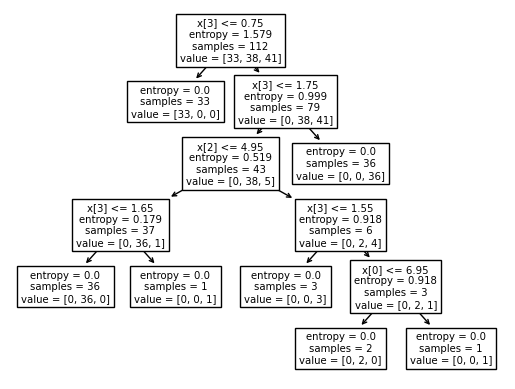

In [19]:
_ = tree.plot_tree(dtc_a)

In [20]:
print(tree.export_text(dtc_a))

|--- feature_3 <= 0.75
|   |--- class: 0
|--- feature_3 >  0.75
|   |--- feature_3 <= 1.75
|   |   |--- feature_2 <= 4.95
|   |   |   |--- feature_3 <= 1.65
|   |   |   |   |--- class: 1
|   |   |   |--- feature_3 >  1.65
|   |   |   |   |--- class: 2
|   |   |--- feature_2 >  4.95
|   |   |   |--- feature_3 <= 1.55
|   |   |   |   |--- class: 2
|   |   |   |--- feature_3 >  1.55
|   |   |   |   |--- feature_0 <= 6.95
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- feature_0 >  6.95
|   |   |   |   |   |--- class: 2
|   |--- feature_3 >  1.75
|   |   |--- class: 2



In [21]:
dtc_b.print_tree()

|> (root) Decision Node - Divided by threshold 2.5999999999999996 on feature [:,2] (dataset column)
|--> Leaf node (<= 2.5999999999999996)
|  |--> class: [0.] with probs [1.]
|--> (> 2.5999999999999996) Decision Node - Divided by threshold 1.75 on feature [:,3] (dataset column)
|----> (<= 1.75) Decision Node - Divided by threshold 4.95 on feature [:,2] (dataset column)
|------> (<= 4.95) Decision Node - Divided by threshold 1.65 on feature [:,3] (dataset column)
|--------> Leaf node (<= 1.65)
|        |--> class: [1.] with probs [1.]
|--------> Leaf node (> 1.65)
|        |--> class: [2.] with probs [1.]
|------> (> 4.95) Decision Node - Divided by threshold 1.55 on feature [:,3] (dataset column)
|--------> Leaf node (<= 1.55)
|        |--> class: [2.] with probs [1.]
|--------> (> 1.55) Decision Node - Divided by threshold 6.75 on feature [:,0] (dataset column)
|----------> Leaf node (<= 6.75)
|          |--> class: [1.] with probs [1.]
|----------> Leaf node (> 6.75)
|          |--> 

In [22]:
y_pred_a = dtc_a.predict(X_test)
y_pred_b = dtc_b.predict(X_test)

In [23]:
# Accuracy of sklearn decision tree
metrics.accuracy_score(y_true=Y_test, y_pred=y_pred_a)

0.9736842105263158

In [24]:
# Accuracy of our decision tree
metrics.accuracy_score(y_true=Y_test, y_pred=y_pred_b)

0.9736842105263158

In [25]:
# Comparasion of the predictions of both decision trees
metrics.accuracy_score(y_true=y_pred_a, y_pred=y_pred_b)

1.0

<h1>Cross Validation</h1>

In [26]:
from itertools import product

def dict_cartesian_product(dic : dict):
    return (dict(zip(dic.keys(), values)) for values in product(*dic.values()))

In [27]:
warnings.filterwarnings("ignore")
def CV(X, Y, hiperparametros : dict, splits=8, th : Theshold = Theshold(type="best")):
    fuera_cv = StratifiedKFold(n_splits=splits, shuffle=True, random_state=0)

    hp_combinaciones = list(dict_cartesian_product(hiperparametros))
    resultados = []

    for ixs_train_fuera, ixs_test_fuera in fuera_cv.split(X, Y):
        # Datos de entrenamiento para el bucle exterior
        X_train_fuera = X.iloc[ixs_train_fuera]
        Y_train_fuera = Y.iloc[ixs_train_fuera]
        # Datos de test del bucle exterior
        X_test_fuera = X.iloc[ixs_test_fuera]
        Y_test_fuera = Y.iloc[ixs_test_fuera]
            
        for i,params in enumerate(hp_combinaciones):
            try:
                model = DecisionTree(**params)
            except:
                # Si la combinación de paráemtros no 
                # es correcta, continuar
                continue
            
            data = pd.concat([X_train_fuera, Y_train_fuera], axis=1)
            model.fit(data, th)

            y_pred = model.predict(X_test_fuera)
            acc = metrics.accuracy_score(y_true=Y_test_fuera.to_numpy(), y_pred=y_pred)
            
            resultados.append({
                **params,
                'accuracy': acc,
                'model': model,
                'num_leafs': model.root.num_leafs(),
                'max_depth': model.root.max_depth(),
                'min_depth': model.root.min_depth(),
                'avg_depth': model.root.avg_depth()
            })

    return resultados

In [28]:
def get_pareto_front(values):
    values = values.flatten()
    is_pareto = np.zeros_like(values)

    is_pareto[0] = 1
    last_best = values[0]
    for i,x in enumerate(values[1:], start=1):
        if x > last_best:
            is_pareto[i] = 1
            last_best = x

    return is_pareto == 1

In [29]:
import matplotlib.pyplot as plt

def pareto_plot(df, x_column, y_column='accuracy', save_as=None):
    df = df[[x_column,y_column]].sort_values(x_column)
    is_pareto = get_pareto_front(df[y_column].to_numpy())

    plt.scatter(df[x_column][~is_pareto], df[y_column][~is_pareto], color='blue')
    plt.plot(df[x_column][is_pareto], df[y_column][is_pareto], color='green')
    plt.xlabel(x_column.capitalize())
    plt.ylabel(y_column.capitalize())

    plt.tight_layout()
    if save_as:
        plt.savefig(save_as+".png")
    plt.show()

In [30]:
hiperparametros = {
    "min_info_gain": (0,0.05,0.1),
    "max_depth": (2,3,4,5,6,7,8,9,10),
    "min_samples_split":(2,3,4,5,6,7,8,9,10),
    "min_samples_leaf": (1,2,3,4,5,6,7,8,9,10),
}

In [31]:
data = pd.read_csv("lenses.csv")
data['Age'].replace(['young', 'pre-presbyopic', 'presbyopic'], [0, 1, 2], inplace=True)
data['Prescription'].replace(['myope', 'hypermetrope'], [0, 1], inplace=True)
data['Astigmatic'].replace(['no', 'yes'], [0, 1], inplace=True)
data['TearRate'].replace(['reduced', 'normal'], [0, 1], inplace=True)
X = pd.DataFrame(data.iloc[:,:-1].values)
Y = pd.DataFrame(data.iloc[:,-1].values.reshape(-1,1))

In [32]:
results = CV(X, Y, hiperparametros, splits=4, th=Theshold(type="custom", th_array=[
    [0.5, 1.5], # Age [0-2]
    [0.5], # Prescription [0-1]
    [0.5], # Astigmatic [0-1]
    [0.5], # Tear Rate [0-1]
]))
results = pd.DataFrame(results)

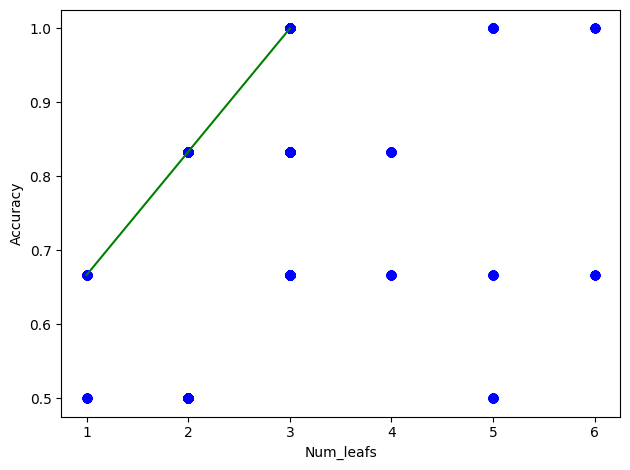

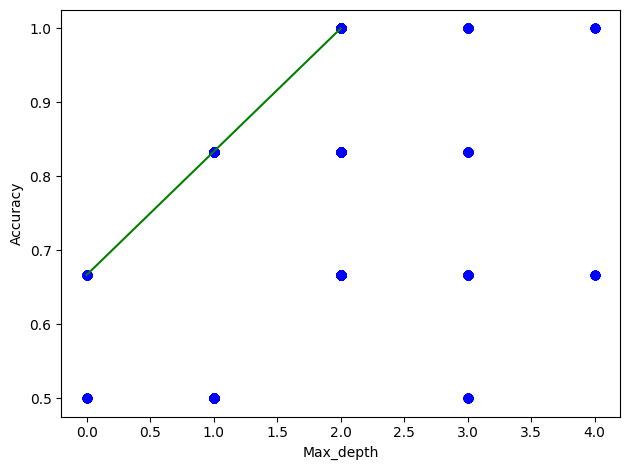

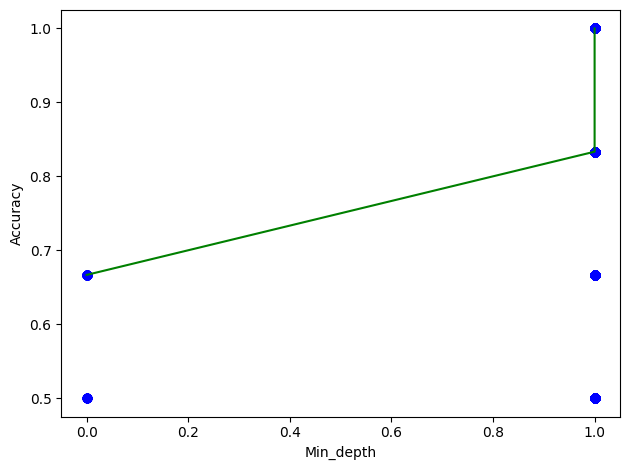

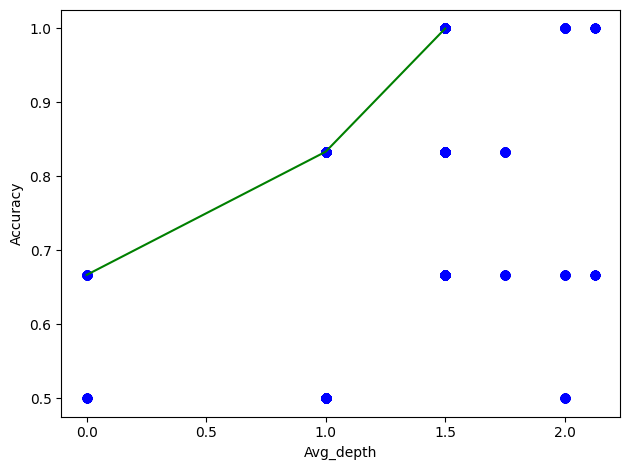

In [33]:
pareto_plot(results, 'num_leafs', save_as='lenses_num_leafs')
pareto_plot(results, 'max_depth', save_as='lenses_max_depth')
pareto_plot(results, 'min_depth', save_as='lenses_min_depth')
pareto_plot(results, 'avg_depth', save_as='lenses_avg_depth')

In [34]:
res_interpretable = results[results['num_leafs']==3].iloc[0]
res_interpretable['model'].print_tree()

|> (root) Decision Node - Divided by threshold 0.5 on feature [:,3] (dataset column)
|--> Leaf node (<= 0.5)
|  |--> class: ['no lenses'] with probs [1.]
|--> (> 0.5) Decision Node - Divided by threshold 0.5 on feature [:,2] (dataset column)
|----> Leaf node (<= 0.5)
|    |--> class: ['no lenses' 'soft'] with probs [0.2 0.8]
|----> Leaf node (> 0.5)
|    |--> class: ['hard' 'no lenses'] with probs [0.6 0.4]


In [35]:
data = pd.read_csv("lenses2.csv")
data['Prescription'].replace(['myope', 'hypermetrope'], [0, 1], inplace=True)
data['Astigmatic'].replace(['no', 'yes'], [0, 1], inplace=True)
data['TearRate'].replace(['reduced', 'normal'], [0, 1], inplace=True)
X = pd.DataFrame(data.iloc[:,:-1].values)
Y = pd.DataFrame(data.iloc[:,-1].values.reshape(-1,1))

In [36]:
results = CV(X, Y, hiperparametros, splits=4, th=Theshold(type="custom", th_array=[
    [20.0, 30.0, 40.0, 50.0, 60.0], # Age [17-70]
    [0.5], # Prescription [0-1]
    [0.5], # Astigmatic [0-1]
    [0.5], # Tear Rate [0-1]
]))
results = pd.DataFrame(results)

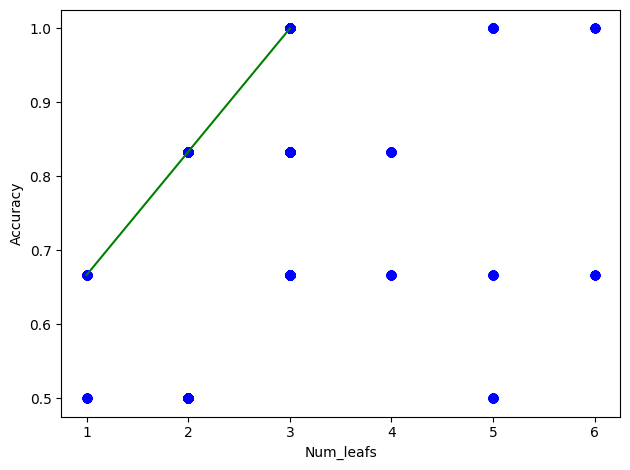

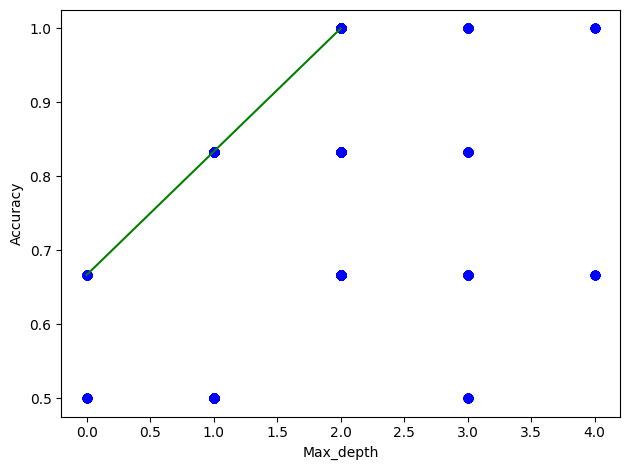

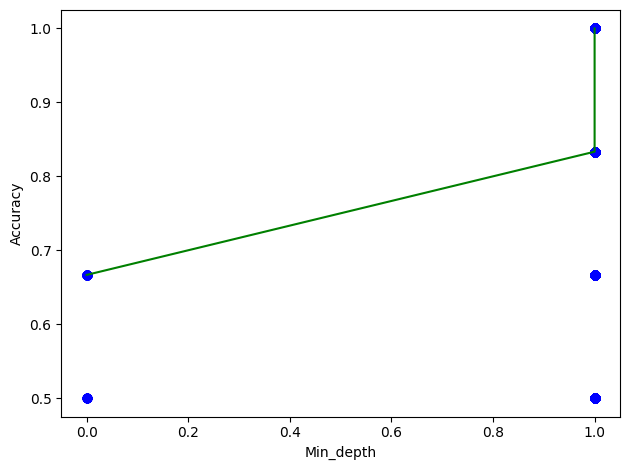

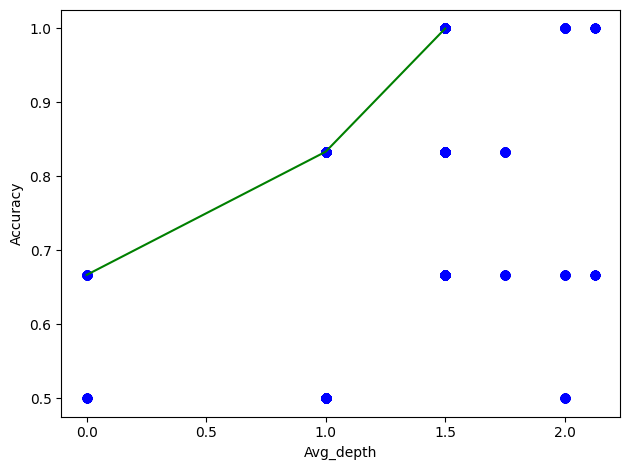

In [37]:
pareto_plot(results, 'num_leafs', save_as='lenses2_num_leafs')
pareto_plot(results, 'max_depth', save_as='lenses2_max_depth')
pareto_plot(results, 'min_depth', save_as='lenses2_min_depth')
pareto_plot(results, 'avg_depth', save_as='lenses2_avg_depth')

In [38]:
data.columns

Index(['Age', 'Prescription', 'Astigmatic', 'TearRate', 'Label'], dtype='object')

In [39]:
res_interpretable = results[results['num_leafs']==5].iloc[0]
res_interpretable['model'].print_tree()

|> (root) Decision Node - Divided by threshold 0.5 on feature [:,3] (dataset column)
|--> Leaf node (<= 0.5)
|  |--> class: ['no lenses'] with probs [1.]
|--> (> 0.5) Decision Node - Divided by threshold 0.5 on feature [:,2] (dataset column)
|----> (<= 0.5) Decision Node - Divided by threshold 40.0 on feature [:,0] (dataset column)
|------> Leaf node (<= 40.0)
|      |--> class: ['soft'] with probs [1.]
|------> Leaf node (> 40.0)
|      |--> class: ['no lenses' 'soft'] with probs [0.5 0.5]
|----> (> 0.5) Decision Node - Divided by threshold 0.5 on feature [:,1] (dataset column)
|------> Leaf node (<= 0.5)
|      |--> class: ['hard'] with probs [1.]
|------> Leaf node (> 0.5)
|      |--> class: ['hard' 'no lenses'] with probs [0.33333333 0.66666667]


In [40]:
res_interpretable

min_info_gain                                                     0.0
max_depth                                                           3
min_samples_split                                                   2
min_samples_leaf                                                    1
accuracy                                                          1.0
model                <__main__.DecisionTree object at 0x76aa37d562c0>
num_leafs                                                           5
min_depth                                                           1
avg_depth                                                         2.0
Name: 45, dtype: object

<h1>COMPARACIÓN MLP</h1>

In [41]:
warnings.filterwarnings("ignore")
@ignore_warnings(category=ConvergenceWarning)
def mlp_CV(X, Y, hiperparametros : dict, splits=8):
    fuera_cv = StratifiedKFold(n_splits=splits, shuffle=True, random_state=0)

    hp_combinaciones = list(dict_cartesian_product(hiperparametros))
    resultados = []

    sca = StandardScaler()
    X = sca.fit_transform(X, Y)
    X = pd.DataFrame(X)
    
    for ixs_train_fuera, ixs_test_fuera in fuera_cv.split(X, Y):
        # Datos de entrenamiento para el bucle exterior
        X_train_fuera = X.iloc[ixs_train_fuera]
        Y_train_fuera = Y.iloc[ixs_train_fuera]

        # Datos de test del bucle exterior
        X_test_fuera = X.iloc[ixs_test_fuera]
        Y_test_fuera = Y.iloc[ixs_test_fuera]
            
        for i,params in enumerate(hp_combinaciones):
            try:
                model = MLPClassifier(**params, random_state=4213)
            except:
                # Si la combinación de paráemtros no 
                # es correcta, continuar
                continue
            
            model.fit(X_train_fuera, Y_train_fuera)

            #model.fit(data, Theshold(type="custom", th_array=[]))
            #model.fit(data, Theshold(type="best"))

            y_pred = model.predict(X_test_fuera)
            acc = metrics.accuracy_score(y_true=Y_test_fuera.to_numpy(), y_pred=y_pred)
            
            resultados.append({
                **params,
                'accuracy': acc,
                'model': model,
            })

    return resultados

In [42]:
hiperparametros_mlp = {
    "hidden_layer_sizes": ([4], [8], [3,3], [4,4], [4,8,4], [3,6,3]),
    "max_iter": (200, 400, 600, 800, 1000),
    "learning_rate_init": (0.001, 0.01, 0.1),
    'solver': ('adam', 'sgd'),  # Optimization algorithms
}
r_mlp = mlp_CV(X, Y, hiperparametros_mlp)
r_mlp = pd.DataFrame(r_mlp)
r_mlp.head()

,hidden_layer_sizes,max_iter,learning_rate_init,solver,accuracy,model
0,[4],200,0.001,adam,0.333333,"MLPClassifier(hidden_layer_sizes=[4], random_s..."
1,[4],200,0.001,sgd,0.666667,"MLPClassifier(hidden_layer_sizes=[4], random_s..."
2,[4],200,0.010,adam,1.000000,"MLPClassifier(hidden_layer_sizes=[4], learning..."
3,[4],200,0.010,sgd,1.000000,"MLPClassifier(hidden_layer_sizes=[4], learning..."
4,[4],200,0.100,adam,1.000000,"MLPClassifier(hidden_layer_sizes=[4], learning..."


In [43]:
percentil_90 = r_mlp['accuracy'].quantile(0.9)
sub_df = r_mlp[r_mlp['accuracy'] >= percentil_90]
sub_df

,hidden_layer_sizes,max_iter,learning_rate_init,solver,accuracy,model
2,[4],200,0.01,adam,1.0,"MLPClassifier(hidden_layer_sizes=[4], learning..."
3,[4],200,0.01,sgd,1.0,"MLPClassifier(hidden_layer_sizes=[4], learning..."
4,[4],200,0.10,adam,1.0,"MLPClassifier(hidden_layer_sizes=[4], learning..."
5,[4],200,0.10,sgd,1.0,"MLPClassifier(hidden_layer_sizes=[4], learning..."
8,[4],400,0.01,adam,1.0,"MLPClassifier(hidden_layer_sizes=[4], learning..."
...,...,...,...,...,...,...
1432,"[3, 6, 3]",800,0.10,adam,1.0,"MLPClassifier(hidden_layer_sizes=[3, 6, 3], le..."
1433,"[3, 6, 3]",800,0.10,sgd,1.0,"MLPClassifier(hidden_layer_sizes=[3, 6, 3], le..."
1437,"[3, 6, 3]",1000,0.01,sgd,1.0,"MLPClassifier(hidden_layer_sizes=[3, 6, 3], le..."
1438,"[3, 6, 3]",1000,0.10,adam,1.0,"MLPClassifier(hidden_layer_sizes=[3, 6, 3], le..."


In [44]:
def plot_mean_stdev(data, labels, save_as=None):
    means, stdevs = [],[]
    for d in data:
        means.append(np.mean(d))
        stdevs.append(np.std(d))

    # Plotting
    plt.bar(labels, means, yerr=stdevs, capsize=5)
    plt.axhline(y=means[0], color='r', linestyle='--', label=f'media mlp {round(means[0], 3)}')
    plt.axhline(y=means[1], color='g', linestyle='--', label=f'media tree {round(means[1], 3)}')

    plt.xlabel('Data Points')
    plt.ylabel('Percentage')
    plt.title('Bar Plot with Standard Deviation')
    plt.legend()
    if save_as:
        plt.savefig(save_as+".png")
    plt.show()

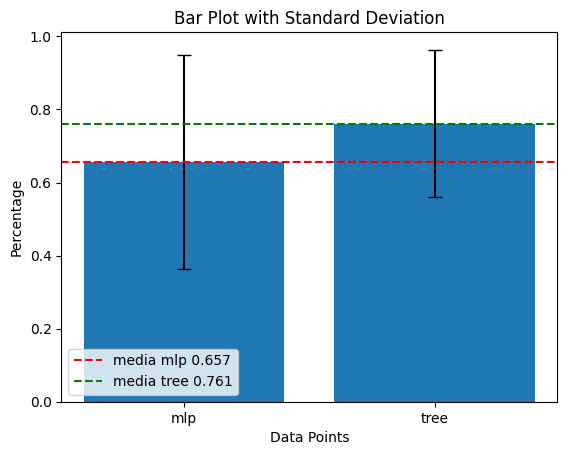

In [45]:
plot_mean_stdev(
    [r_mlp["accuracy"], [results["accuracy"]]], 
    labels=["mlp", "tree"],
    save_as="comparacion_lenses"
)

<h1>Comparación con el Iris dataset</h1>

In [46]:
iris_data = pd.read_csv("Iris.csv").drop("Id", axis=1)
iris_data["Species"] = iris_data["Species"].map({'Iris-setosa': 0, "Iris-versicolor": 1, "Iris-virginica": 2})
X = pd.DataFrame(iris_data.iloc[:,:-1].values)
Y = pd.DataFrame(iris_data.iloc[:,-1].values.reshape(-1,1))

In [47]:
hiperparametros = {
    "min_info_gain": (0,),
    "max_depth": (3,4,5,6,7),
    "min_samples_split":(2, 4, 6, 8),
    "min_samples_leaf": (1,2,3,4),
}
r_tree = CV(X, Y, hiperparametros, splits=4)
r_tree = pd.DataFrame(r_tree)

In [48]:
hiperparametros_mlp = {
    "hidden_layer_sizes": ([4], [8], [3,3], [3,6,3]),
    "max_iter": (200, 600, 1000),
    "learning_rate_init": (0.01, 0.1),
    'solver': ('adam',),  # Optimization algorithms
}
r_mlp = mlp_CV(X, Y, hiperparametros_mlp)
r_mlp = pd.DataFrame(r_mlp)

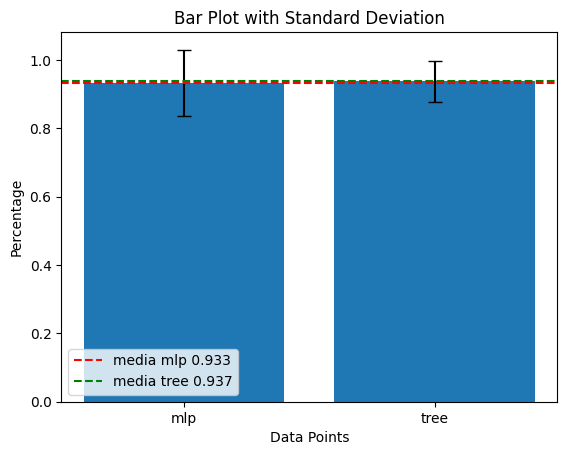

In [49]:
plot_mean_stdev(
    [r_mlp["accuracy"], [r_tree["accuracy"]]], 
    labels=["mlp", "tree"],
    save_as="comparacion_iris"
)

In [50]:
res_interpretable = r_tree.sort_values('accuracy', ascending=False).iloc[0]
res_interpretable

min_info_gain                                                       0
max_depth                                                           5
min_samples_split                                                   8
min_samples_leaf                                                    1
accuracy                                                          1.0
model                <__main__.DecisionTree object at 0x76aa380e5ba0>
num_leafs                                                           7
min_depth                                                           1
avg_depth                                                      2.1875
Name: 104, dtype: object

In [51]:
iris_data.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [52]:
res_interpretable['model'].print_tree()

|> (root) Decision Node - Divided by threshold 2.45 on feature [:,2] (dataset column)
|--> Leaf node (<= 2.45)
|  |--> class: [0.] with probs [1.]
|--> (> 2.45) Decision Node - Divided by threshold 4.75 on feature [:,2] (dataset column)
|----> (<= 4.75) Decision Node - Divided by threshold 7.05 on feature [:,0] (dataset column)
|------> Leaf node (<= 7.05)
|      |--> class: [1.] with probs [1.]
|------> Leaf node (> 7.05)
|      |--> class: [1.] with probs [1.]
|----> (> 4.75) Decision Node - Divided by threshold 5.15 on feature [:,2] (dataset column)
|------> (<= 5.15) Decision Node - Divided by threshold 1.75 on feature [:,3] (dataset column)
|--------> Leaf node (<= 1.75)
|        |--> class: [1. 2.] with probs [0.6 0.4]
|--------> (> 1.75) Decision Node - Divided by threshold 4.35 on feature [:,0] (dataset column)
|----------> Leaf node (<= 4.35)
|          |--> class: [1.] with probs [1.]
|----------> Leaf node (> 4.35)
|          |--> class: [2.] with probs [1.]
|------> Leaf no